In [53]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

## Pre-Processing Image

In [77]:
def read_image(image,k):
        img = cv2.imread(image)
        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

        x,y,c = img.shape
        new_x = int(x/4)
        new_y = int(y/4)
        img = cv2.resize(img,(new_x,new_y))
        X = img.reshape((-1,3))

        return X,new_x,new_y

## Finding Dominant Color

In [ ]:
name = input("Enter the file name with type: ")
k = int(input("Enter number of colors to be extracted: "))
X,row,col = read_image(name,k)
model = KMeans(n_clusters=k)
model.fit(X)
centroids = model.cluster_centers_
colors = np.array(centroids,dtype='uint8')

cnt = 1
for color in colors:
        plt.subplot(1,k,cnt)
        cnt += 1
        plt.axis('off')
        mat = np.zeros((100,100,3),dtype='uint8')
        mat[:,:,:] = color
        plt.imshow(mat)
        print(color)
        plt.show()

Enter the file name with type:  color_extraction.jpeg
Enter number of colors to be extracted:  8


## Reconstructing Image

In [59]:
newImg = np.zeros((X.shape[0],3),dtype='uint8')
print(newImg.shape)

(14310, 3)


In [61]:
for i in range(newImg.shape[0]):
    newImg[i] = colors[model.labels_[i]]

In [67]:
newImg.resize((col,row,3))

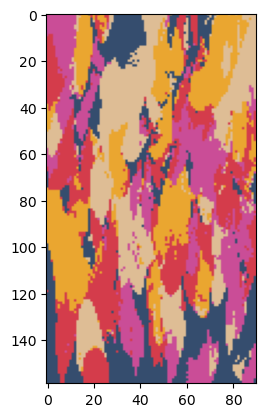

In [69]:
plt.imshow(newImg)